In [2]:
from galpy.potential import NFWPotential
import astropy.units as u
from astropy.cosmology import Planck18
import matplotlib.pyplot as plt
import numpy as np
from galpy.orbit import Orbit

u_dist = u.kpc
u_dens = u.Msun / u.kpc**3


rvir:308.1398863241154 kpc


Text(0, 0.5, '$\\mathrm{M_{\\odot}\\,kpc^{-3}}$')

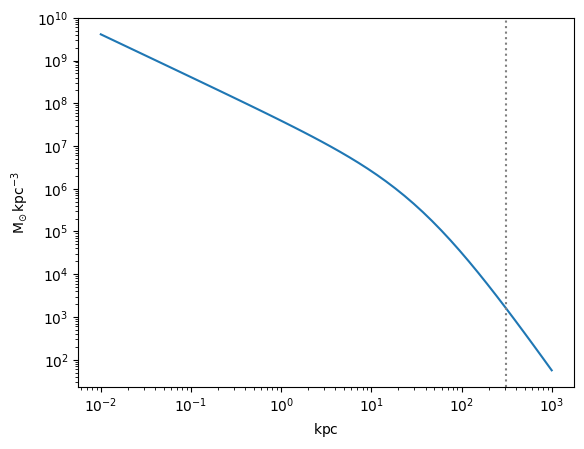

In [3]:
# Define NFW halo
host = NFWPotential(
    conc=8,  # concnetration parameter
    mvir=1  # virial mass in unit of 1e12*Msun
)
rho = lambda r: host.dens(R=r,z=0)
print(f"rvir:{host.rvir()}")

_r = np.logspace(-2,3) * u.kpc
_rho = rho(_r)
plt.loglog(
    _r.to_value(u_dist),
    _rho.to_value(u_dens)
    )
plt.axvline(host.rvir().to_value(u_dist),c="gray",linestyle=":")
plt.xlabel(u_dist.to_string("latex_inline"))
plt.ylabel(u_dens.to_string("latex_inline"))

In [5]:
# orbit integration
from galpy.actionAngle import actionAngleTorus  # (action,angle) --> (x,v)
from galpy.actionAngle import actionAngleTorus_c
aAT = actionAngleTorus(pot=host)
jr,lz,jz = 0.1,1.0,0.1  # actions in unit of L_circ(R=1)
Om = aAT.Freqs(jr,lz,jz)  # frequencies
Om

RuntimeError: actionAngleTorus instances cannot be used, because the actionAngleTorus_c extension failed to load